# Steam Games Analysis

What drives a game's reach on Steam, and can it be predicted before launch?

This notebook works through a catalog of ~140,000 Steam games:

1. **Cleaning** the raw export, which turns out to carry several inconsistent schemas
2. **Feature engineering** from the catalog metadata
3. **EDA** on what correlates with reach and reception
4. **Modelling** a game's estimated-owners bucket from information available *before* launch

Source: `steam_games.csv` (~927MB raw).

In [1]:
import json
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RAW_CSV = "../steam_games.csv"
PROCESSED_PARQUET = "../data/processed/games.parquet"
sns.set_theme(style="whitegrid")

## 1. First look at the raw data

The raw file is ~927MB, so we start with a 5-row preview rather than loading all of it.

In [2]:
preview = pd.read_csv(RAW_CSV, nrows=5)
preview

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,...,linux,header_image,screenshots,movies,website,support_url,support_email,metacritic_url,steam_store_available,steam_spy_available
0,876310,BIG POGO MAN,2018-06-25,4.99,paid,0 - 20000,"[""WooJuDev""]","[""WooJuDev""]","[""Adventure"", ""Casual"", ""Indie"", ""Sports""]","[""Single-player"", ""Steam Achievements"", ""Steam...",...,False,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,woojudev@gmail.com,NaN,True,True
1,876320,Hyperspace Delivery Service,2019-06-05,9.99,paid,0 - 20000,"[""Zotnip""]","[""Zotnip""]","[""Action"", ""Adventure"", ""Indie"", ""Simulation"",...","[""Single-player"", ""Steam Achievements"", ""Full ...",...,True,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],http://hyperspacedeliveryservice.com,http://hyperspacedeliveryservice.com,info@zotnip.com,NaN,True,True
2,876340,VR Slots 3D,2018-08-30,0.00,free,0 - 20000,"[""Belka VR""]","[""Belka VR""]","[""Casual"", ""Free To Play"", ""Indie"", ""Early Acc...","[""Single-player"", ""Tracked Controller Support""...",...,False,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,support@belkavr.com,NaN,True,True
3,876380,Underwater hunting,2018-06-20,0.99,paid,0 - 20000,"[""GiBar""]","[""RoBot""]","[""Adventure"", ""Indie"", ""RPG""]","[""Single-player"", ""Multi-player"", ""Co-op"", ""On...",...,False,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,robot72@yandex.ru,NaN,True,True
4,876410,Greenspawn Restaurant,2018-07-20,3.99,paid,0 - 20000,"[""Apple Dash""]","[""Apple Dash""]","[""Action"", ""Indie""]","[""Single-player"", ""Steam Achievements"", ""Famil...",...,True,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,fshpsmgc@gmail.com,NaN,True,True


In [3]:
preview.dtypes

app_id                        int64
name                            str
release_date                    str
price                       float64
price_status                    str
estimated_owners                str
developers                      str
publishers                      str
genres                          str
categories                      str
tags                            str
positive                      int64
negative                      int64
recommendations             float64
peak_ccu                      int64
metacritic_score            float64
user_score                    int64
average_playtime_forever      int64
median_playtime_forever       int64
average_playtime_2weeks       int64
median_playtime_2weeks        int64
short_description               str
about_the_game                  str
detailed_description            str
notes                       float64
achievements                float64
dlc_count                     int64
packages                    

`genres`, `categories`, `tags`, `developers` and `publishers` all come back as strings. Their values *look* like lists — `["Action", "Indie"]` — but pandas has no reason to parse them, so they stay text for now. Section 3 handles that.

## 2. Loading the full catalog

Most of the raw file's bulk is text and URLs we will never model on: full game descriptions, screenshot and video links, support emails. Passing `usecols` means pandas' parser skips those columns entirely rather than loading and then discarding them.

In [4]:
all_columns = pd.read_csv(RAW_CSV, nrows=0).columns.tolist()

drop_columns = [
    "about_the_game", "detailed_description", "notes", "header_image",
    "screenshots", "movies", "website", "support_url", "support_email",
    "metacritic_url",
]

usecols = [c for c in all_columns if c not in drop_columns]

# low_memory=False reads the file in a single pass. Besides avoiding pandas'
# chunked dtype guessing, it sidesteps a bug in pandas 3.0.5 that raises an
# IndexError while building the mixed-dtype warning for this file.
df = pd.read_csv(RAW_CSV, usecols=usecols, low_memory=False)

print(df.shape)
df.info(memory_usage="deep")

(139580, 32)
<class 'pandas.DataFrame'>
RangeIndex: 139580 entries, 0 to 139579
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    139580 non-null  int64  
 1   name                      139564 non-null  str    
 2   release_date              139497 non-null  str    
 3   price                     138408 non-null  float64
 4   price_status              139580 non-null  str    
 5   estimated_owners          139580 non-null  str    
 6   developers                139580 non-null  str    
 7   publishers                139580 non-null  str    
 8   genres                    139580 non-null  str    
 9   categories                139580 non-null  str    
 10  tags                      139580 non-null  str    
 11  positive                  139580 non-null  int64  
 12  negative                  139580 non-null  int64  
 13  recommendations           107968 non-null 

## 3. Cleaning: four inconsistent schemas in one file

The list-like columns are not stored consistently across rows. Each of the issues below surfaced only as a downstream error, traced back to the offending value — none are visible in the first few rows:

| Issue | Example | Rows affected | Handling |
| --- | --- | --- | --- |
| A single value stored as a bare string instead of a JSON array | `supported_languages` = `English` rather than `["English"]` | few | wrap in a one-item list |
| Genres/categories stored as objects rather than names | `[{"id": "4", "description": "Casual"}, ...]` | few | keep the `description` value |
| Tags stored as a name → vote-count mapping instead of a list | `{"Indie": 131, "Action": 126, ...}` | ~23,500 | keep the keys |
| Platform flags mixing booleans with missing values | `windows` ∈ {`True`, `False`, `NaN`} | 15 | treat missing as `False` |

The tag vote counts are richer than what the other ~116,000 rows carry, but they cannot be used consistently across the dataset, so only the tag names are kept.

**Missing-value semantics.** A missing list is treated as "nothing listed" (`[]`) rather than "unknown", because for these columns the two amount to the same thing: a game with no `full_audio_languages` entry has no recorded full audio support. `description_length` is handled differently — see section 5.

In [5]:
parse_columns = [
    "genres", "categories", "tags", "developers", "publishers",
    "supported_languages", "full_audio_languages",
]


def parse_list(value):
    """Parse a JSON-encoded list cell, tolerating the schema variations above."""
    if isinstance(value, (list, dict)):
        return value  # already parsed; keeps the cell safe to re-run
    if pd.isna(value) or value == "":
        return []
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return [value]  # a bare string, e.g. supported_languages = "English"


def normalize_items(value):
    """Reduce a parsed cell to a flat list of names, whatever shape it arrived in."""
    if isinstance(value, dict):
        return list(value.keys())  # tags stored as name -> vote count
    return [
        item.get("description", str(item)) if isinstance(item, dict) else item
        for item in value
    ]


for col in parse_columns:
    df[col] = df[col].apply(parse_list).apply(normalize_items)

In [6]:
# Every parsed column should now hold plain lists of strings, and nothing else.
for col in parse_columns:
    top_level = set(df[col].apply(type))
    assert top_level == {list}, f"{col} holds non-list values: {top_level}"

    elements = {type(item) for lst in df[col] for item in lst}
    assert elements <= {str}, f"{col} holds non-string elements: {elements}"

print("all parsed columns hold lists of strings")

all parsed columns hold lists of strings


In [7]:
# Platform flags carry NaN alongside True/False, which forces the column to
# dtype object. Missing is read as "not supported".
for col in ["windows", "mac", "linux"]:
    df[col] = df[col].fillna(False).astype(bool)

df[["windows", "mac", "linux"]].dtypes

windows    bool
mac        bool
linux      bool
dtype: object

## 4. Feature engineering

Every feature here comes from information a developer would know *before* release — how the game is tagged, what it costs, which platforms it ships on. Post-launch signals (reviews, playtime, concurrent players) are deliberately left out of the model; including them would leak the outcome we are trying to predict.

In [8]:
for col in parse_columns:
    df[col + "_count"] = df[col].apply(len)

# The booleans are cast before summing: adding bool Series directly returns a
# boolean "any platform" result rather than a 0-3 count.
df["platform_count"] = (
    df["windows"].astype(int) + df["mac"].astype(int) + df["linux"].astype(int)
)

df["has_achievements"] = df["achievements"].fillna(0) > 0

df["platform_count"].value_counts().sort_index()

platform_count
0        17
1    110512
2     16559
3     12492
Name: count, dtype: int64

`positive_ratio` is EDA-only — it summarizes post-launch reception, so it is excluded from the model's features (see the leakage note in the modelling section). Dividing by zero reviews would otherwise silently become `NaN` via plain float division; the explicit `np.where` makes that "no signal yet" case visible in the code rather than relying on the reader to know the float-division quirk.

In [9]:
total_reviews = df["positive"] + df["negative"]
df["positive_ratio"] = np.where(total_reviews > 0, df["positive"] / total_reviews, np.nan)

df["positive_ratio"].isna().sum()
print(((df['positive'] == 0) & (df['negative'] == 0)).sum())

56519


In [10]:
df["price"].describe()

count    138408.000000
mean          9.025464
std         411.111628
min           0.000000
25%           0.990000
50%           4.990000
75%           9.990000
max      107500.000000
Name: price, dtype: float64

The median game is \$4.99 and the 75th percentile \$9.99, but the maximum is \$107,500 — an outlier that inflates the standard deviation to ~411. Rather than guess a ceiling that such values would silently fall outside of (landing them in an unbinned `NaN`), the top bucket is left open with `np.inf`.

In [11]:
# The first edge sits just below zero so that free games (price == 0.00) land
# in their own bucket; pd.cut's intervals exclude the left edge.
df["price_bucket"] = pd.cut(
    df["price"],
    bins=[-0.01, 0, 5, 20, np.inf],
    labels=["free", "budget", "mid", "premium"],
)

df["price_bucket"].value_counts()

price_bucket
budget     54953
mid        48861
free       27781
premium     6813
Name: count, dtype: int64

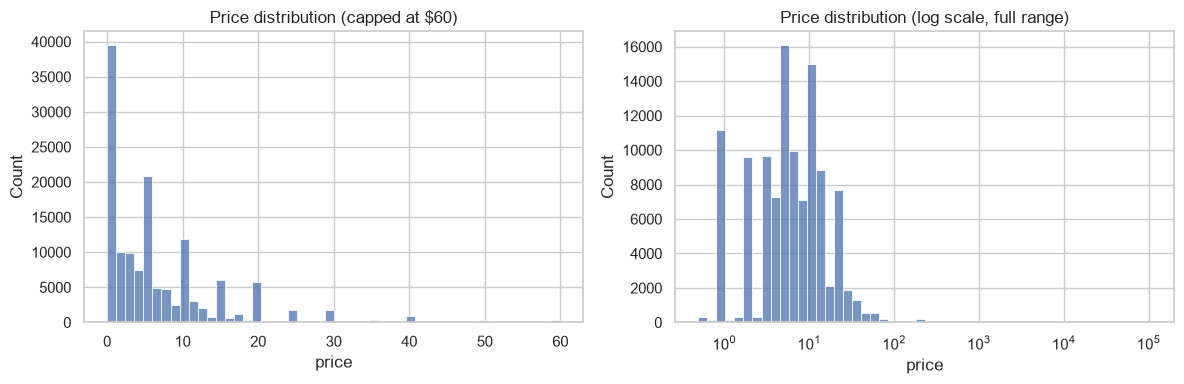

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df[df['price'] <= 60], x='price', bins=50, ax=axes[0])
axes[0].set_title('Price distribution (capped at $60)')

sns.histplot(data=df, x='price', bins=50, log_scale=True, ax=axes[1])
axes[1].set_title('Price distribution (log scale, full range)')

plt.tight_layout()

Prices cluster at conventional "charm price" points ($0.99, $4.99, $9.99, $14.99, $19.99, $29.99) rather than spreading smoothly across the range — developers anchor to these tiers by convention, producing a comb-like distribution instead of a bell curve. The tall spike at $0 is free-to-play games. On the log-scale view, the $107,500 outlier from `describe()` is essentially invisible: it is a single row, not a cluster, so it cannot form a visible bar even when the axis is compressed.

## 5. Dates and description length

`errors="coerce"` turns unparseable dates into `NaT` instead of raising — the same defensive stance the list parsing needed.

`description_length` keeps `NaN` where a game has no short description, rather than filling zero: a missing description is of unknown length, not zero length, and collapsing the two would tell the model that ~8,000 games have unusually terse store pages.

In [13]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

df["description_length"] = df["short_description"].str.len()

df["release_year"].value_counts().sort_index()

release_year
1997.0        2
1998.0        1
1999.0        2
2000.0        2
2001.0        4
2002.0        1
2003.0        3
2004.0        6
2005.0        7
2006.0       69
2007.0       90
2008.0      158
2009.0      321
2010.0      255
2011.0      258
2012.0      322
2013.0      467
2014.0     1521
2015.0     2513
2016.0     4137
2017.0     5918
2018.0     7451
2019.0     7240
2020.0     8795
2021.0    11044
2022.0    12255
2023.0    14538
2024.0    19899
2025.0    24687
2026.0    17531
Name: count, dtype: int64

In [14]:
engineered = [
    "genres_count", "categories_count", "tags_count", "supported_languages_count",
    "platform_count", "has_achievements", "price_bucket", "description_length",
    "release_year", "release_month",
]

df[engineered].info()

<class 'pandas.DataFrame'>
RangeIndex: 139580 entries, 0 to 139579
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   genres_count               139580 non-null  int64   
 1   categories_count           139580 non-null  int64   
 2   tags_count                 139580 non-null  int64   
 3   supported_languages_count  139580 non-null  int64   
 4   platform_count             139580 non-null  int64   
 5   has_achievements           139580 non-null  bool    
 6   price_bucket               138408 non-null  category
 7   description_length         131250 non-null  float64 
 8   release_year               139497 non-null  float64 
 9   release_month              139497 non-null  float64 
dtypes: bool(1), category(1), float64(3), int64(5)
memory usage: 8.8 MB


## 6. The target variable

`estimated_owners` arrives pre-bucketed as ranges, but the raw file encodes them inconsistently — a fifth schema issue, on top of the four in section 3. The same range appears in two different string formats depending on the row, e.g. `"20000 - 50000"` and `"20,000 .. 50,000"` are the same bucket. Left alone, this would fragment 14 real categories into 26, silently hurting any model trained on it.

In [15]:
def normalize_owners(label):
    """Collapse both raw formats (e.g. "20000 - 50000" and "20,000 .. 50,000")
    into one canonical string per range."""
    numbers = re.findall(r"[\d,]+", label)
    low, high = (int(n.replace(",", "")) for n in numbers)
    return f"{low} - {high}"


df["estimated_owners"] = df["estimated_owners"].apply(normalize_owners)

In [16]:
owners = df["estimated_owners"].value_counts()
print(owners)
print()
print((owners / len(df) * 100).round(2).astype(str) + "%")

estimated_owners
0 - 20000                92772
0 - 0                    21185
20000 - 50000            11410
50000 - 100000            5369
100000 - 200000           3469
200000 - 500000           2864
500000 - 1000000          1157
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

estimated_owners
0 - 20000                66.47%
0 - 0                    15.18%
20000 - 50000             8.17%
50000 - 100000            3.85%
100000 - 200000           2.49%
200000 - 500000           2.05%
500000 - 1000000          0.83%
1000000 - 2000000         0.52%
2000000 - 5000000         0.29%
5000000 - 10000000        0.09%
10000000 - 20000000       0.04%
20000000 - 50000000       0.02%
50000000 - 100000000      0.01%
100000000 - 200000000      0.0%
Name: count, dtype: str


Normalizing collapses 26 raw labels into 14 real buckets — but it also exposes a severe class imbalance: 66.47% of games fall in the lowest bucket (`0 - 20000`), another 15.18% have zero recorded owners, and the top bucket (`100000000 - 200000000`) holds only 4 games out of 139,580. A classifier trained naively here could reach high raw accuracy just by always predicting the majority bucket, so the modelling section evaluates with class-aware metrics (e.g. per-class F1) rather than accuracy alone.

## 7. What genres, tags, and platforms dominate the catalog

`genres` and `tags` are list columns — one game can carry several — so counting how often each value appears requires `explode()`, which turns a row's list into one row per item before counting. Platform support is already boolean, so it just needs summing.

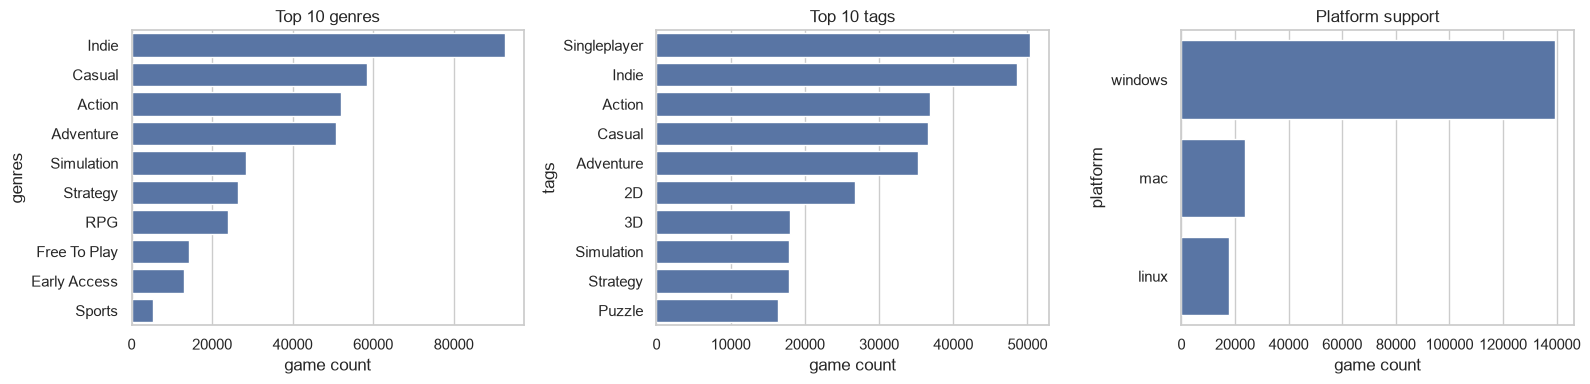

In [17]:
top_genres = df.explode("genres")["genres"].value_counts().head(10)
top_tags = df.explode("tags")["tags"].value_counts().head(10)
platform_support = df[["windows", "mac", "linux"]].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0])
axes[0].set_title("Top 10 genres")
axes[0].set_xlabel("game count")

sns.barplot(x=top_tags.values, y=top_tags.index, ax=axes[1])
axes[1].set_title("Top 10 tags")
axes[1].set_xlabel("game count")

sns.barplot(x=platform_support.values, y=platform_support.index, ax=axes[2])
axes[2].set_title("Platform support")
axes[2].set_xlabel("game count")
axes[2].set_ylabel("platform")

plt.tight_layout()

Indie accounts for 66.5% of all games in the catalog — the single largest genre by a wide margin over the next closest, Casual. This lines up with Steam being flooded with small and solo-developer releases.

"Singleplayer" is the single most common tag, ahead of every genre. This is a supply-side signal, not evidence of player preference: the dataset counts what got built and published, not what players chose to play. Singleplayer games are cheaper and simpler for small Indie teams to build than multiplayer ones — no netcode, matchmaking, or server infrastructure — so the tag's dominance likely reflects what is easy to produce at this scale, not player demand.

The same story shows up in platform support: Windows is essentially universal (~139K games) while Mac (~23K) and Linux (~18K) are a small minority. From section 4's `platform_count` breakdown, 110,512 games support only one platform against just 12,492 that support all three — porting and maintaining builds for multiple platforms is extra engineering effort, so most small teams target only the platform with the largest install base and stop there.

## 8. Price vs. owners bucket

`estimated_owners` is a string column, so pandas has no idea `"20000 - 50000"` comes before `"100000 - 200000"` — a plain alphabetical sort would misorder them. `owner_order` sorts the bucket labels by their actual numeric bounds so every chart in this section displays the buckets correctly, smallest to largest.

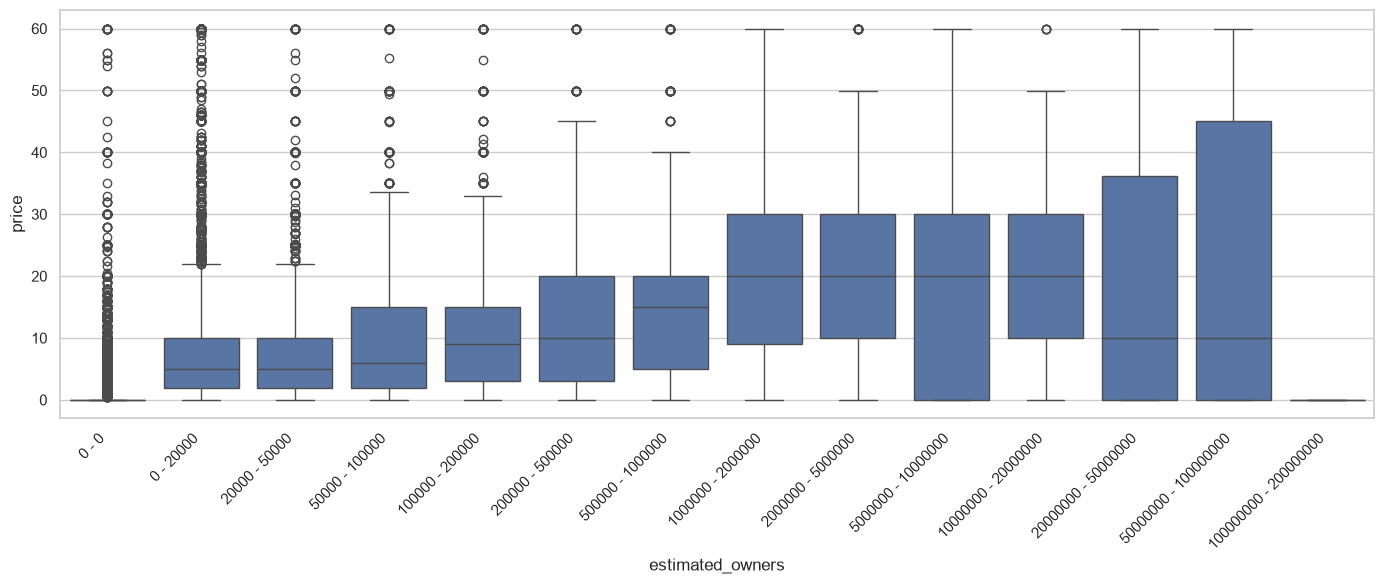

In [18]:
def bucket_bounds(label):
    low, high = label.split(' - ')
    return int(low), int(high)

owner_order = sorted(df['estimated_owners'].unique(), key=bucket_bounds)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['price'] <= 60], x='estimated_owners', y='price', order=owner_order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

The chart shows that higher owners buckets tend to have a higher median price, which runs counter to the assumption that cheaper games sell more. The flattest boxes at the top of the chart shouldn't be read too literally, though — the `100000000 - 200000000` bucket has only 4 games, `50000000 - 100000000` has 9, and `20000000 - 50000000` has 31. With that few data points, a single unusual value can flatten the whole box, so the apparent "biggest hits are free" pattern likely reflects insufficient data rather than a real trend.

## 9. Platform, genre, and tag counts vs. owners bucket

tags_count
21        2
20    33494
19     2678
18     2812
17     2890
16     2819
15     2663
14     2597
13     2491
12     2445
Name: count, dtype: int64

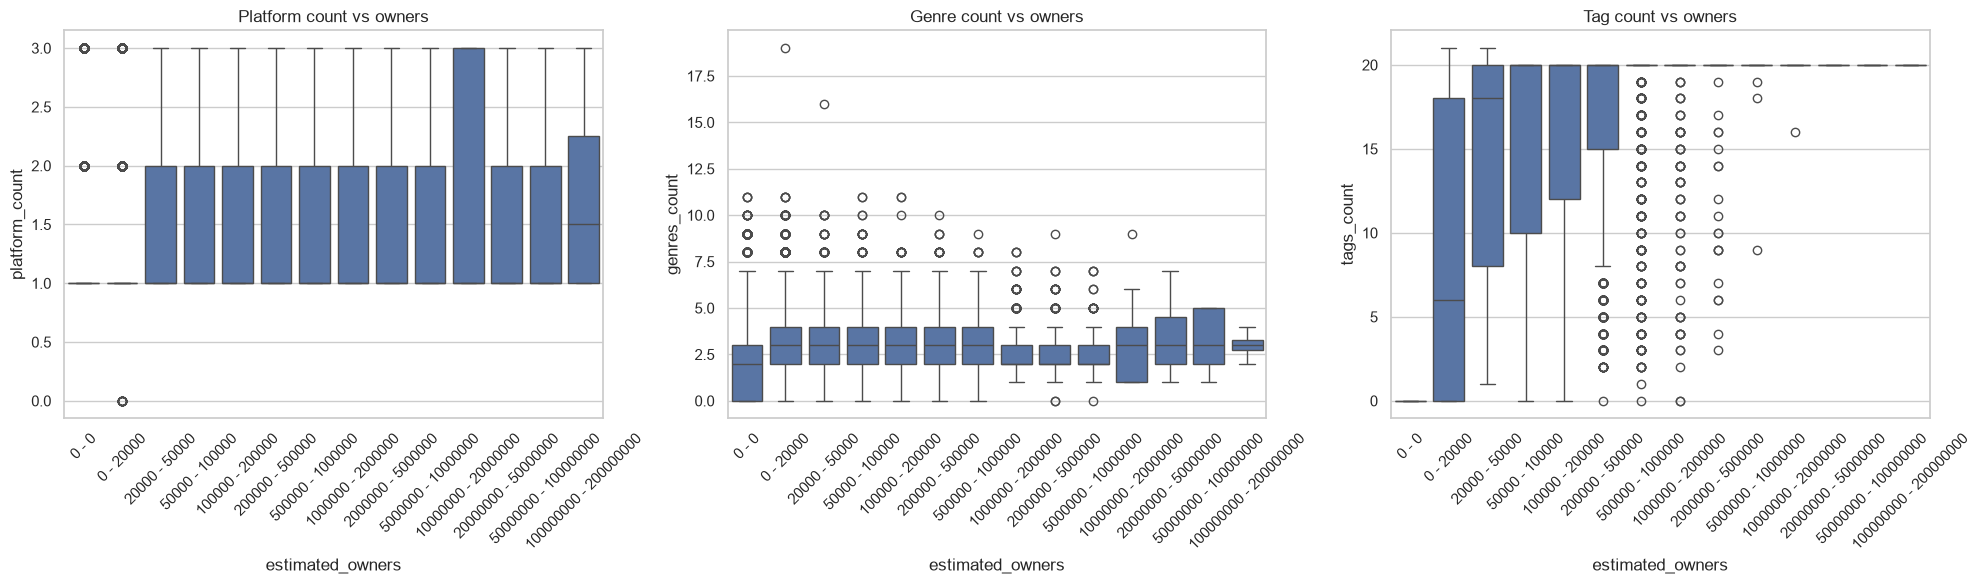

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='estimated_owners', y='platform_count', order=owner_order, ax=axes[0])
axes[0].set_title('Platform count vs owners')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='estimated_owners', y='genres_count', order=owner_order, ax=axes[1])
axes[1].set_title('Genre count vs owners')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='estimated_owners', y='tags_count', order=owner_order, ax=axes[2])
axes[2].set_title('Tag count vs owners')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

df['tags_count'].value_counts().sort_index(ascending=False).head(10)

Platform count shows a mild upward trend with owners (median climbs from 1 in the smallest buckets to 2 in most mid/large ones) — bigger, more successful titles can justify the extra engineering cost of porting to Mac and Linux. Genre count stays essentially flat across buckets and doesn't discriminate much on its own.

Tag count is the interesting one: from roughly the `200000 - 500000` bucket upward, the box collapses to a tight sliver sitting almost exactly at 20. That's worth investigating directly rather than trusting the chart at face value.

In [20]:
df['tags_count'].value_counts().sort_index(ascending=False).head(10)

tags_count
21        2
20    33494
19     2678
18     2812
17     2890
16     2819
15     2663
14     2597
13     2491
12     2445
Name: count, dtype: int64

**A sixth data limitation: `tags_count` is capped, not organic.** 33,494 games sit at *exactly* 20 tags, while every neighboring count is far smaller and roughly smooth (19 → 2,678, 18 → 2,812, 17 → 2,890, ... 21 → only 2). A real, uncapped tagging process wouldn't produce a 12x spike at one specific number followed by an almost total drop-off — that pattern is the signature of a hard cutoff. Whatever scraper produced this Kaggle dataset appears to have only recorded up to 20 tags per game, silently truncating anything beyond that.

This is a different kind of issue than the four schema inconsistencies in section 3: nothing here is malformed, every value is a valid integer, but the column can no longer distinguish games above the cap from each other. A game with 22 real community tags and one with 2,000 both read as `20`. That is exactly why the box plot flattens for popular games: it is not that hit games "settle" around 20 tags, it is that the dataset cannot see past 20 for them. `tags_count` should be treated as a reliable signal only below the cap; above it, its value is an artifact of collection, not of the game's real popularity.

In [ ]:
comparison = pd.crosstab(df['estimated_owners'], df['price_status'], normalize='index') * 100
comparison = comparison.reindex(owner_order)
comparison

Free games' share climbs steadily through the middle buckets (roughly 13-17%) and then jumps sharply at the top: 28% at 5-10M owners, 35.5% at 20-50M, 44.4% at 50-100M, and 100% at the very top bucket (100-200M). Games that reach massive scale skew free-to-play far more than the rest of the catalog — removing the purchase barrier is one of the most effective ways to maximize install count.

This also refines a caveat from section 8: the price-vs-owners box plot showed a flat box at $0 for the top bucket, which was attributed there mainly to having only 4 games. This table shows it is not just a small-sample artifact — all 4 of those games are genuinely free. The small sample size still limits how far this should be generalized, but the flat box was accurate, not noise.

In [ ]:
df['price_status'].value_counts()

A third `price_status` value shows up here that hasn't come up yet: `unavailable`, at 4,230 games (~3%). Worth a quick investigation rather than assuming what it means.

In [ ]:
df[df['price_status'] == 'unavailable']['price'].isna().sum()

In [ ]:
pd.crosstab(df['price_status'], df['steam_store_available'])

**A seventh data limitation: `price_status = "unavailable"` doesn't mean what it sounds like.** Two hypotheses, tested and ruled out:

- *"No price was ever recorded"* — false. Only 428 of the 4,230 `unavailable` rows actually have a missing `price`; the rest carry a real value.
- *"Delisted from the store"* — false. 4,215 of the 4,230 still show `steam_store_available = True`.

The most likely remaining explanation is a scraping artifact: whatever process built this Kaggle dataset probably fetched live pricing separately from the rest of a game's metadata, and for these ~3% of games that specific fetch failed or was rate-limited, independent of whether the game's store page itself was reachable. `unavailable` most likely means "pricing could not be confirmed at scrape time," not a real fact about the game. Left as-is in the data (relabeling it "free" or "paid" would be guessing), but worth knowing before drawing conclusions from `price_status` elsewhere.

## 11. Export

Parquet stores the parsed list columns natively, so reloading needs no re-parsing, and it compresses the heavily repeated genre and tag strings well — 927MB of raw CSV lands at roughly 32MB, small enough to commit and to load straight into the dashboard app.

In [22]:
os.makedirs(os.path.dirname(PROCESSED_PARQUET), exist_ok=True)
df.to_parquet(PROCESSED_PARQUET, index=False)

print(f"{os.path.getsize(PROCESSED_PARQUET) / (1024 * 1024):.1f} MB")

31.7 MB
